In [1]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, roc_auc_score

In [2]:
df = pd.read_csv("dataset/dataset_updated.csv")

# pastikan label:
# 1 = legitimate
# 0 = phishing

X = df.drop(['URL', 'ClassLabel'], axis=1)
y = df['ClassLabel']

In [4]:
import pandas as pd

# load dataset
df = pd.read_csv("dataset/dataset_updated.csv")

# cek NaN
print(df.isnull().sum())

# hapus baris yang ada NaN
df = df.dropna()

# pastikan label cuma 0 dan 1
df = df[df['ClassLabel'].isin([0,1])]

URL                          0
url_length                   0
has_ip_address               0
dot_count                    0
https_flag                   0
url_entropy                  0
token_count                  0
subdomain_count              0
query_param_count            0
tld_length                   0
path_length                  0
has_hyphen_in_domain         0
number_of_digits             0
tld_popularity               0
suspicious_file_extension    0
domain_name_length           0
percentage_numeric_chars     0
ClassLabel                   1
dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(["ClassLabel", "URL"], axis=1)
y = df["ClassLabel"]

# STEP 1 → 70% train
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# STEP 2 → 15% val & 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 70939
Validation: 15201
Test: 15202


In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [8]:
# Decision Tree (baseline)
dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

# Random Forest (MODEL UTAMA 🔥)
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)

# Logistic Regression (baseline)
lr = LogisticRegression(
    max_iter=1000
)

In [6]:
print(X_train.dtypes)

url_length                     int64
has_ip_address                 int64
dot_count                      int64
https_flag                     int64
url_entropy                  float64
token_count                    int64
subdomain_count                int64
query_param_count              int64
tld_length                     int64
path_length                    int64
has_hyphen_in_domain           int64
number_of_digits               int64
tld_popularity                 int64
suspicious_file_extension      int64
domain_name_length             int64
percentage_numeric_chars     float64
dtype: object


In [10]:
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [11]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

import matplotlib.pyplot as plt

In [13]:
def evaluate_model(name, model, X_test, y_test):
    print(f"\n=== {name} ===")

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    # METRICS
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc:.4f}")

    # CLASSIFICATION REPORT
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # CONFUSION MATRIX
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    return acc, prec, rec, f1, roc


=== Decision Tree ===
Accuracy  : 0.9988
Precision : 0.9977
Recall    : 0.9991
F1-Score  : 0.9984
ROC-AUC   : 0.9993

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      9557
         1.0       1.00      1.00      1.00      5645

    accuracy                           1.00     15202
   macro avg       1.00      1.00      1.00     15202
weighted avg       1.00      1.00      1.00     15202



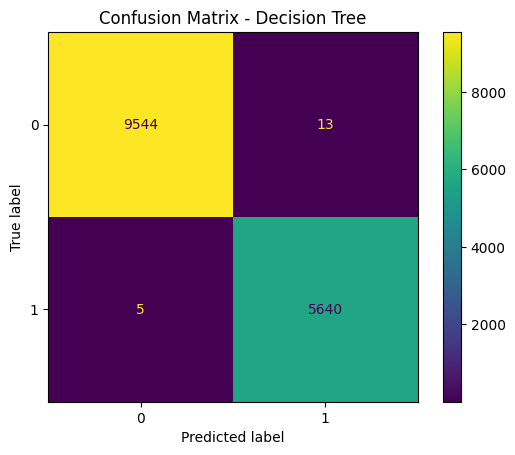


=== Random Forest ===
Accuracy  : 0.9995
Precision : 0.9995
Recall    : 0.9993
F1-Score  : 0.9994
ROC-AUC   : 1.0000

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      9557
         1.0       1.00      1.00      1.00      5645

    accuracy                           1.00     15202
   macro avg       1.00      1.00      1.00     15202
weighted avg       1.00      1.00      1.00     15202



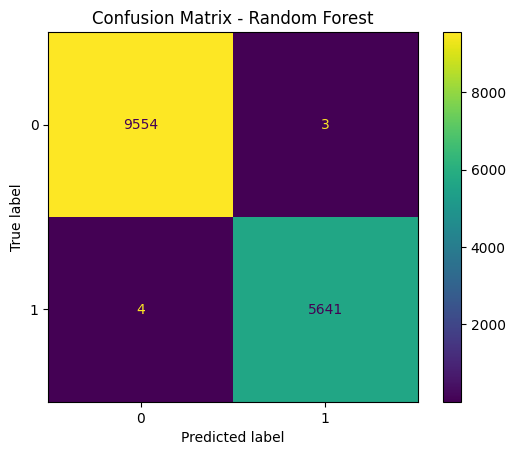


=== Logistic Regression ===
Accuracy  : 0.9966
Precision : 0.9928
Recall    : 0.9981
F1-Score  : 0.9954
ROC-AUC   : 0.9999

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      9557
         1.0       0.99      1.00      1.00      5645

    accuracy                           1.00     15202
   macro avg       1.00      1.00      1.00     15202
weighted avg       1.00      1.00      1.00     15202



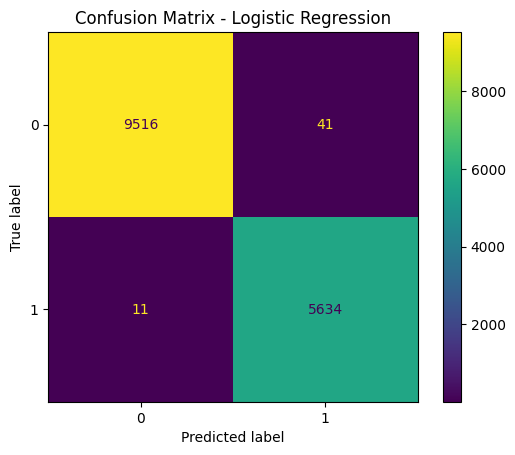

In [14]:
dt_metrics = evaluate_model("Decision Tree", dt, X_test, y_test)
rf_metrics = evaluate_model("Random Forest", rf, X_test, y_test)
lr_metrics = evaluate_model("Logistic Regression", lr, X_test, y_test)

In [15]:
pickle.dump(dt, open("model/dt_model1.pkl", "wb"))
pickle.dump(rf, open("model/rf_model1.pkl", "wb"))
pickle.dump(lr, open("model/lr_model1.pkl", "wb"))